# Parte 1 — Estadística descriptiva e inferencial

**Proyecto:** AndinaRetail S.A.C.  
**Notebook:** `notebooks/01_estadistica.ipynb`  
**Dataset:** oficial v1 congelado en `datos/`  
**Salidas:** `resultados/resumen_estadistico.csv` y `resultados/pruebas_hipotesis.csv`

Este notebook implementa la Parte 1 del proyecto usando los CSV oficiales. El flujo sigue la especificación funcional y el diccionario de datos: carga del dataset, preparación de vistas analíticas, estadística descriptiva, análisis de faltantes/outliers y contraste de las hipótesis H1 a H4.

## 1. Configuración y reproducibilidad

Se fija la semilla `2026`, se usan rutas relativas al repositorio y se crean las carpetas necesarias para resultados. El notebook no modifica los CSV oficiales; solo genera resultados derivados.

In [1]:
from __future__ import annotations

from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 2026
rng = np.random.default_rng(SEED)

# El notebook está diseñado para ejecutarse desde la carpeta notebooks/.
# Si se ejecuta desde la raíz del repo, también resuelve las rutas correctamente.
CURRENT = Path.cwd()
if CURRENT.name == "notebooks":
    ROOT = CURRENT.parent
else:
    ROOT = CURRENT

DATA_DIR = ROOT / "datos"
RESULTS_DIR = ROOT / "resultados"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATHS = {
    "tiendas": DATA_DIR / "tiendas.csv",
    "productos": DATA_DIR / "productos.csv",
    "clientes": DATA_DIR / "clientes.csv",
    "ventas": DATA_DIR / "ventas.csv",
    "inventario": DATA_DIR / "inventario.csv",
}

OUT_RESUMEN = RESULTS_DIR / "resumen_estadistico.csv"
OUT_PRUEBAS = RESULTS_DIR / "pruebas_hipotesis.csv"

pd.options.display.float_format = "{:,.4f}".format

print(f"ROOT: {ROOT}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"RESULTS_DIR: {RESULTS_DIR}")

ROOT: C:\Users\ca\OneDrive\Desktop\proyecto-andinaretail
DATA_DIR: C:\Users\ca\OneDrive\Desktop\proyecto-andinaretail\datos
RESULTS_DIR: C:\Users\ca\OneDrive\Desktop\proyecto-andinaretail\resultados


## 2. Evidencia del dataset oficial v1

La Parte 1 se ejecuta sobre el dataset oficial v1. Se revisa la existencia de los cinco CSV congelados, el archivo de versión y el reporte de validación aprobado.

In [2]:
for nombre, ruta in CSV_PATHS.items():
    if not ruta.exists():
        raise FileNotFoundError(f"No se encontró el CSV requerido: {ruta}")
    print(f"[OK] {nombre}: {ruta.relative_to(ROOT)}")

version_path = DATA_DIR / "DATASET_VERSION.md"
validation_report = RESULTS_DIR / "reporte_validacion_datos.txt"

if version_path.exists():
    print("\nDATASET_VERSION.md:")
    print("\n".join(version_path.read_text(encoding="utf-8").splitlines()[:18]))
else:
    print("\n[WARN] No se encontró datos/DATASET_VERSION.md")

if validation_report.exists():
    reporte = validation_report.read_text(encoding="utf-8")
    for linea in reporte.splitlines()[:8]:
        print(linea)
else:
    print("\n[WARN] No se encontró resultados/reporte_validacion_datos.txt")

[OK] tiendas: datos\tiendas.csv
[OK] productos: datos\productos.csv
[OK] clientes: datos\clientes.csv
[OK] ventas: datos\ventas.csv
[OK] inventario: datos\inventario.csv

DATASET_VERSION.md:
# Dataset oficial v1 — AndinaRetail S.A.C.

## Estado

Dataset oficial congelado para las Partes 1 a 5 del proyecto.

## Versión

- Versión del dataset: v1
- Semilla de generación: 2026
- Versión de configuración: 1.3.0
- Estado de validación: APROBADO

## Archivos congelados

- `datos/tiendas.csv`
- `datos/productos.csv`
- `datos/clientes.csv`
Reporte de validacion de datos — AndinaRetail S.A.C.
Estado general: APROBADO
Version config: 1.3.0
Semilla: 2026

Validaciones correctas: 121
Advertencias: 1


## 3. Carga de datos

Se cargan las cinco tablas oficiales: `tiendas`, `productos`, `clientes`, `ventas` e `inventario`.

In [3]:
tiendas = pd.read_csv(CSV_PATHS["tiendas"])
productos = pd.read_csv(CSV_PATHS["productos"])
clientes = pd.read_csv(CSV_PATHS["clientes"])
ventas = pd.read_csv(CSV_PATHS["ventas"])
inventario = pd.read_csv(CSV_PATHS["inventario"])

tablas = {
    "tiendas": tiendas,
    "productos": productos,
    "clientes": clientes,
    "ventas": ventas,
    "inventario": inventario,
}

resumen_carga = pd.DataFrame({
    "tabla": list(tablas.keys()),
    "filas": [len(df) for df in tablas.values()],
    "columnas": [df.shape[1] for df in tablas.values()],
})
display(resumen_carga)

,tabla,filas,columnas
0,tiendas,15,8
1,productos,800,8
2,clientes,15000,9
3,ventas,250000,12
4,inventario,432000,8


## 4. Preparación de vistas derivadas

De acuerdo con la especificación, la Parte 1 construye vistas a nivel de línea, ticket, cliente y ciudad-mes. Las métricas financieras se calculan desde los CSV oficiales sin alterar los archivos fuente.

In [4]:
# Tipos de fecha.
ventas = ventas.copy()
clientes = clientes.copy()
productos = productos.copy()
tiendas = tiendas.copy()
inventario = inventario.copy()

ventas["fecha_dt"] = pd.to_datetime(ventas["fecha"])
clientes["fecha_registro_dt"] = pd.to_datetime(clientes["fecha_registro"])

# Vista a nivel de línea enriquecida con producto y tienda.
productos_min = productos[["id_producto", "categoria", "costo_unitario", "precio_lista"]].copy()
tiendas_min = (
    tiendas[["id_tienda", "tipo", "canal", "ciudad", "region"]]
    .rename(columns={"canal": "canal_tienda", "ciudad": "ciudad_tienda", "region": "region_tienda"})
)

linea = (
    ventas
    .merge(productos_min, on="id_producto", how="left")
    .merge(tiendas_min, on="id_tienda", how="left")
)

linea["venta_bruta"] = linea["cantidad"] * linea["precio_unitario"]
linea["descuento_monto"] = linea["venta_bruta"] * linea["descuento_pct"]
linea["costo_mercaderia"] = linea["cantidad"] * linea["costo_unitario"]
linea["margen_bruto"] = linea["monto_total"] - linea["costo_mercaderia"]
linea["margen_bruto_pct"] = linea["margen_bruto"] / linea["monto_total"]
linea["grupo_canal"] = np.where(linea["canal"].eq("Tienda"), "Fisico", "Digital")
linea["periodo_mes"] = linea["fecha_dt"].dt.to_period("M").astype(str)

# Vista a nivel de ticket.
ticket = (
    linea.groupby("id_venta", as_index=False)
    .agg(
        fecha=("fecha", "first"),
        id_cliente=("id_cliente", "first"),
        id_tienda=("id_tienda", "first"),
        canal=("canal", "first"),
        metodo_pago=("metodo_pago", "first"),
        ticket_total=("monto_total", "sum"),
        cantidad_total=("cantidad", "sum"),
        lineas_ticket=("id_linea", "count"),
    )
)
ticket["fecha_dt"] = pd.to_datetime(ticket["fecha"])
ticket["grupo_canal"] = np.where(ticket["canal"].eq("Tienda"), "Fisico", "Digital")

# Categoría principal del ticket: mayor suma de monto_total dentro del ticket; empate alfabético.
categoria_ticket = (
    linea.groupby(["id_venta", "categoria"], as_index=False)["monto_total"]
    .sum()
    .sort_values(["id_venta", "monto_total", "categoria"], ascending=[True, False, True])
    .drop_duplicates("id_venta")
    [["id_venta", "categoria"]]
    .rename(columns={"categoria": "categoria_ticket"})
)
ticket = ticket.merge(categoria_ticket, on="id_venta", how="left")

# Vista ciudad-mes solo para tiendas físicas.
linea_fisica = linea[linea["tipo"].eq("Fisica")].copy()

ventas_ciudad_mes = (
    linea_fisica.groupby(["ciudad_tienda", "periodo_mes"], as_index=False)
    .agg(
        ventas_netas=("monto_total", "sum"),
        margen_bruto=("margen_bruto", "sum"),
    )
)

inventario_enriquecido = inventario.merge(tiendas_min, on="id_tienda", how="left")
inventario_fisico = inventario_enriquecido[inventario_enriquecido["tipo"].eq("Fisica")].copy()

costo_ciudad_mes = (
    inventario_fisico.groupby(["ciudad_tienda", "periodo"], as_index=False)["costo_almacenamiento"]
    .sum()
    .rename(columns={"periodo": "periodo_mes"})
)

ciudad_mes = ventas_ciudad_mes.merge(costo_ciudad_mes, on=["ciudad_tienda", "periodo_mes"], how="left")
ciudad_mes["costo_almacenamiento"] = ciudad_mes["costo_almacenamiento"].fillna(0)
ciudad_mes["margen_operativo"] = ciudad_mes["margen_bruto"] - ciudad_mes["costo_almacenamiento"]
ciudad_mes["margen_operativo_pct"] = ciudad_mes["margen_operativo"] / ciudad_mes["ventas_netas"]

print("Vista línea:", linea.shape)
print("Vista ticket:", ticket.shape)
print("Vista cliente:", clientes.shape)
print("Vista ciudad-mes:", ciudad_mes.shape)

display(linea.head())
display(ticket.head())
display(ciudad_mes.head())

Vista línea: (250000, 27)
Vista ticket: (100000, 12)
Vista cliente: (15000, 10)
Vista ciudad-mes: (180, 7)


,id_linea,id_venta,fecha,id_cliente,id_tienda,id_producto,cantidad,precio_unitario,descuento_pct,monto_total,...,canal_tienda,ciudad_tienda,region_tienda,venta_bruta,descuento_monto,costo_mercaderia,margen_bruto,margen_bruto_pct,grupo_canal,periodo_mes
0,L0000001,V000001,2025-03-02,C14714,WEB,P0362,1,72.6400,0.0490,69.0800,...,Web,NaN,NaN,72.6400,3.5594,51.1400,17.9400,0.2597,Digital,2025-03
1,L0000002,V000001,2025-03-02,C14714,WEB,P0486,7,157.5000,0.1796,904.4900,...,Web,NaN,NaN,"1,102.5000",198.0090,694.6800,209.8100,0.2320,Digital,2025-03
2,L0000003,V000002,2023-07-06,C12369,T001,P0520,2,63.4000,0.0918,115.1600,...,Tienda,Lima,Costa,126.8000,11.6402,81.9200,33.2400,0.2886,Fisico,2023-07
3,L0000004,V000002,2023-07-06,C12369,T001,P0493,1,177.1000,0.0000,177.1000,...,Tienda,Lima,Costa,177.1000,0.0000,117.0400,60.0600,0.3391,Fisico,2023-07
4,L0000005,V000002,2023-07-06,C12369,T001,P0567,3,14.8000,0.1025,39.8500,...,Tienda,Lima,Costa,44.4000,4.5510,27.1200,12.7300,0.3194,Fisico,2023-07


,id_venta,fecha,id_cliente,id_tienda,canal,metodo_pago,ticket_total,cantidad_total,lineas_ticket,fecha_dt,grupo_canal,categoria_ticket
0,V000001,2025-03-02,C14714,WEB,Web,Tarjeta credito,973.5700,8,2,2025-03-02,Digital,Cuidado Personal
1,V000002,2023-07-06,C12369,T001,Tienda,Efectivo,332.1100,6,3,2023-07-06,Fisico,Cuidado Personal
2,V000003,2023-09-16,C09839,T009,Tienda,Tarjeta debito,"2,030.1600",6,4,2023-09-16,Fisico,Electrohogar
3,V000004,2023-09-17,C00763,T001,Tienda,Efectivo,68.4100,1,1,2023-09-17,Fisico,Abarrotes
4,V000005,2025-06-18,C12552,T011,Tienda,Tarjeta debito,215.2500,3,1,2025-06-18,Fisico,Abarrotes


,ciudad_tienda,periodo_mes,ventas_netas,margen_bruto,costo_almacenamiento,margen_operativo,margen_operativo_pct
0,Arequipa,2023-01,"340,196.2600","93,436.1800","43,969.6400","49,466.5400",0.1454
1,Arequipa,2023-02,"308,179.8100","85,697.0700","41,504.2900","44,192.7800",0.1434
2,Arequipa,2023-03,"447,069.7400","126,112.7900","39,354.8600","86,757.9300",0.1941
3,Arequipa,2023-04,"385,427.5900","107,039.2400","37,345.8000","69,693.4400",0.1808
4,Arequipa,2023-05,"417,565.6200","116,578.7600","35,920.5200","80,658.2400",0.1932


## 5. Aptitud estadística previa

Antes de ejecutar hipótesis, se verifican condiciones mínimas: tickets físicos/digitales, ciudades durante 2025-04 a 2025-12, categorías, métodos de pago y variabilidad en descuento/cantidad.

In [5]:
checks = []

checks.append(("H1_tickets_fisicos", int((ticket["grupo_canal"] == "Fisico").sum())))
checks.append(("H1_tickets_digitales", int((ticket["grupo_canal"] == "Digital").sum())))

periodo_h2 = ciudad_mes[(ciudad_mes["periodo_mes"] >= "2025-04") & (ciudad_mes["periodo_mes"] <= "2025-12")]
checks.append(("H2_ciudades_periodo_afectado", int(periodo_h2["ciudad_tienda"].nunique())))
checks.append(("H2_observaciones_ciudad_mes", int(len(periodo_h2))))

checks.append(("H3_categorias_ticket", int(ticket["categoria_ticket"].nunique())))
checks.append(("H3_metodos_pago", int(ticket["metodo_pago"].nunique())))

checks.append(("H4_variabilidad_descuento", float(linea["descuento_pct"].std())))
checks.append(("H4_variabilidad_cantidad", float(linea["cantidad"].std())))

aptitud = pd.DataFrame(checks, columns=["criterio", "valor_observado"])
display(aptitud)

,criterio,valor_observado
0,H1_tickets_fisicos,"70,781.0000"
1,H1_tickets_digitales,"29,219.0000"
2,H2_ciudades_periodo_afectado,5.0000
3,H2_observaciones_ciudad_mes,45.0000
4,H3_categorias_ticket,6.0000
5,H3_metodos_pago,5.0000
6,H4_variabilidad_descuento,0.0509
7,H4_variabilidad_cantidad,1.7317


## 6. Estadística descriptiva

Se calculan medidas de tendencia central, dispersión y forma para variables clave: ventas, tickets, clientes, cantidades, descuentos y márgenes.

In [6]:
def moda_serie(s: pd.Series):
    moda = s.dropna().mode()
    return moda.iloc[0] if len(moda) else np.nan

def resumen_numerico(df: pd.DataFrame, variable: str, nivel: str, descripcion: str) -> dict:
    s = pd.to_numeric(df[variable], errors="coerce")
    validos = s.dropna()
    return {
        "tipo": "numerica",
        "nivel": nivel,
        "variable": variable,
        "descripcion": descripcion,
        "n": len(s),
        "n_validos": len(validos),
        "n_nulos": int(s.isna().sum()),
        "media": validos.mean(),
        "mediana": validos.median(),
        "moda": moda_serie(validos),
        "desviacion_estandar": validos.std(ddof=1),
        "min": validos.min(),
        "q1": validos.quantile(0.25),
        "q3": validos.quantile(0.75),
        "iqr": validos.quantile(0.75) - validos.quantile(0.25),
        "p95": validos.quantile(0.95),
        "max": validos.max(),
        "asimetria": validos.skew(),
        "curtosis": validos.kurtosis(),
        "conteo": np.nan,
        "porcentaje": np.nan,
    }

def resumen_categorico(df: pd.DataFrame, variable: str, nivel: str, descripcion: str, top_n: int | None = None) -> list[dict]:
    vc = df[variable].value_counts(dropna=False)
    if top_n is not None:
        vc = vc.head(top_n)
    total = len(df)
    filas = []
    for categoria, conteo in vc.items():
        filas.append({
            "tipo": "categorica",
            "nivel": nivel,
            "variable": variable,
            "descripcion": f"{descripcion}: {categoria}",
            "n": total,
            "n_validos": int(df[variable].notna().sum()),
            "n_nulos": int(df[variable].isna().sum()),
            "media": np.nan,
            "mediana": np.nan,
            "moda": np.nan,
            "desviacion_estandar": np.nan,
            "min": np.nan,
            "q1": np.nan,
            "q3": np.nan,
            "iqr": np.nan,
            "p95": np.nan,
            "max": np.nan,
            "asimetria": np.nan,
            "curtosis": np.nan,
            "conteo": int(conteo),
            "porcentaje": float(conteo / total * 100),
        })
    return filas

resumen_filas = []
resumen_filas.extend([
    resumen_numerico(linea, "monto_total", "linea", "Venta neta por línea"),
    resumen_numerico(ticket, "ticket_total", "ticket", "Total por ticket"),
    resumen_numerico(linea, "cantidad", "linea", "Cantidad vendida por línea"),
    resumen_numerico(clientes, "edad", "cliente", "Edad del cliente"),
    resumen_numerico(linea, "descuento_pct", "linea", "Porcentaje de descuento"),
    resumen_numerico(linea, "margen_bruto_pct", "linea", "Margen bruto porcentual por línea"),
    resumen_numerico(ciudad_mes, "margen_operativo_pct", "ciudad_mes", "Margen operativo porcentual ciudad-mes"),
])

resumen_filas.extend(resumen_categorico(ticket, "canal", "ticket", "Canal del ticket"))
resumen_filas.extend(resumen_categorico(ticket, "grupo_canal", "ticket", "Grupo de canal"))
resumen_filas.extend(resumen_categorico(linea, "categoria", "linea", "Categoría del producto"))
resumen_filas.extend(resumen_categorico(ticket, "metodo_pago", "ticket", "Método de pago"))
resumen_filas.extend(resumen_categorico(clientes, "ciudad", "cliente", "Ciudad del cliente"))
resumen_filas.extend(resumen_categorico(clientes, "segmento", "cliente", "Segmento comercial"))

resumen_estadistico = pd.DataFrame(resumen_filas)
display(resumen_estadistico.head(20))

,tipo,nivel,variable,descripcion,n,n_validos,n_nulos,media,mediana,moda,...,min,q1,q3,iqr,p95,max,asimetria,curtosis,conteo,porcentaje
0,numerica,linea,monto_total,Venta neta por línea,250000,250000,0,429.4519,94.0000,16.1000,...,1.8100,42.3600,263.8600,221.5000,"2,006.6065","52,471.6000",9.0800,156.0781,NaN,NaN
1,numerica,ticket,ticket_total,Total por ticket,100000,100000,0,"1,073.6299",373.8150,28.7500,...,1.9200,146.3700,"1,073.9475",927.5775,"4,527.2490","52,867.9200",5.5415,57.6591,NaN,NaN
2,numerica,linea,cantidad,Cantidad vendida por línea,250000,250000,0,2.0689,2.0000,1.0000,...,1.0000,1.0000,2.0000,1.0000,6.0000,20.0000,3.4686,20.6097,NaN,NaN
3,numerica,cliente,edad,Edad del cliente,15000,14718,282,38.3274,38.0000,18.0000,...,18.0000,30.0000,46.0000,16.0000,58.0000,80.0000,0.2243,-0.3327,NaN,NaN
4,numerica,linea,descuento_pct,Porcentaje de descuento,250000,250000,0,0.0459,0.0327,0.0000,...,0.0000,0.0000,0.0820,0.0820,0.1422,0.3161,0.8602,-0.1227,NaN,NaN
5,numerica,linea,margen_bruto_pct,Margen bruto porcentual por línea,250000,250000,0,0.2351,0.2347,0.2000,...,-0.1856,0.1786,0.3000,0.1214,0.3589,0.3982,-0.2662,-0.3893,NaN,NaN
6,numerica,ciudad_mes,margen_operativo_pct,Margen operativo porcentual ciudad-mes,180,180,0,0.1603,0.1699,0.0350,...,0.0350,0.1354,0.1905,0.0550,0.2117,0.2372,-0.6844,-0.0456,NaN,NaN
7,categorica,ticket,canal,Canal del ticket: Tienda,100000,100000,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"70,781.0000",70.7810
8,categorica,ticket,canal,Canal del ticket: Web,100000,100000,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"14,999.0000",14.9990
9,categorica,ticket,canal,Canal del ticket: App,100000,100000,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"14,220.0000",14.2200


## 7. Faltantes y outliers

Los faltantes y valores atípicos son parte controlada del diseño del dataset. No se eliminan automáticamente; se reportan y se usan análisis de sensibilidad cuando corresponde.

**Nota sobre nulos estructurales:** los nulos observados en `tiendas.ciudad`, `tiendas.region` y `tiendas.area_m2` corresponden a los nodos virtuales `WEB` y `APP`. Son nulos permitidos por el diccionario de datos y no representan un problema de calidad.

In [7]:
faltantes = []
for nombre, df in tablas.items():
    n_filas = len(df)
    for col in df.columns:
        n_null = int(df[col].isna().sum())
        if n_null > 0:
            faltantes.append({
                "tabla": nombre,
                "campo": col,
                "n_nulos": n_null,
                "pct_nulos": n_null / n_filas * 100,
            })

faltantes_df = pd.DataFrame(faltantes).sort_values(["tabla", "campo"]) if faltantes else pd.DataFrame(
    columns=["tabla", "campo", "n_nulos", "pct_nulos"]
)

# Clasificación interpretativa: diferencia nulos estructurales de nulos controlados de calidad.
def clasificar_faltante(row: pd.Series) -> pd.Series:
    tabla = row["tabla"]
    campo = row["campo"]

    if tabla == "tiendas" and campo in {"ciudad", "region", "area_m2"}:
        return pd.Series({
            "tipo_faltante": "Estructural permitido",
            "interpretacion": "Nulo esperado en nodos virtuales WEB y APP; no es problema de calidad.",
        })

    if tabla in {"clientes", "productos"}:
        return pd.Series({
            "tipo_faltante": "Faltante controlado",
            "interpretacion": "Faltante sintético previsto por el diseño del dataset.",
        })

    return pd.Series({
        "tipo_faltante": "Revisar",
        "interpretacion": "No corresponde a un faltante permitido esperado.",
    })

if not faltantes_df.empty:
    faltantes_df = pd.concat(
        [faltantes_df, faltantes_df.apply(clasificar_faltante, axis=1)],
        axis=1,
    )

outliers_cantidad = linea[linea["cantidad"] > 8].copy()
pct_outliers_cantidad = len(outliers_cantidad) / len(linea) * 100

q1_ticket = ticket["ticket_total"].quantile(0.25)
q3_ticket = ticket["ticket_total"].quantile(0.75)
iqr_ticket = q3_ticket - q1_ticket
limite_sup_ticket = q3_ticket + 1.5 * iqr_ticket
outliers_ticket = ticket[ticket["ticket_total"] > limite_sup_ticket]

print("Campos con faltantes:")
display(faltantes_df)

print(f"Líneas con cantidad > 8: {len(outliers_cantidad):,} ({pct_outliers_cantidad:.2f}%)")
print(f"Tickets sobre límite IQR superior: {len(outliers_ticket):,} ({len(outliers_ticket) / len(ticket) * 100:.2f}%)")

Campos con faltantes:


,tabla,campo,n_nulos,pct_nulos,tipo_faltante,interpretacion
7,clientes,canal_preferido,316,2.1067,Faltante controlado,Faltante sintético previsto por el diseño del ...
6,clientes,distrito,309,2.0600,Faltante controlado,Faltante sintético previsto por el diseño del ...
5,clientes,edad,282,1.8800,Faltante controlado,Faltante sintético previsto por el diseño del ...
4,productos,marca,6,0.7500,Faltante controlado,Faltante sintético previsto por el diseño del ...
3,productos,subcategoria,19,2.3750,Faltante controlado,Faltante sintético previsto por el diseño del ...
2,tiendas,area_m2,2,13.3333,Estructural permitido,Nulo esperado en nodos virtuales WEB y APP; no...
0,tiendas,ciudad,2,13.3333,Estructural permitido,Nulo esperado en nodos virtuales WEB y APP; no...
1,tiendas,region,2,13.3333,Estructural permitido,Nulo esperado en nodos virtuales WEB y APP; no...


Líneas con cantidad > 8: 1,250 (0.50%)
Tickets sobre límite IQR superior: 11,473 (11.47%)


## 8. Visualizaciones descriptivas

Se generan gráficos básicos de distribución y comparación. Estas visualizaciones apoyan los supuestos y la interpretación, pero los resultados inferenciales se documentan en la sección de hipótesis.

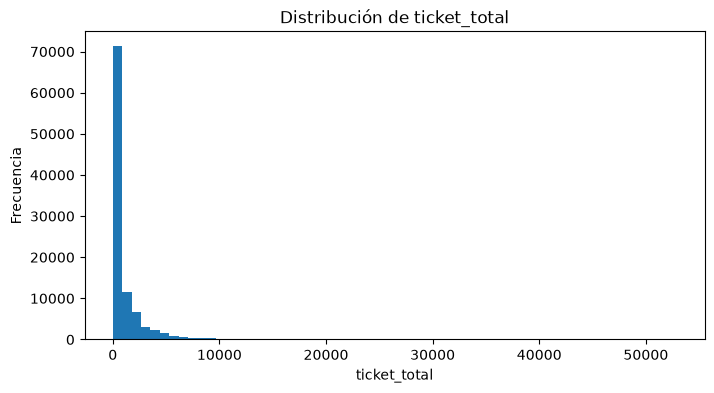

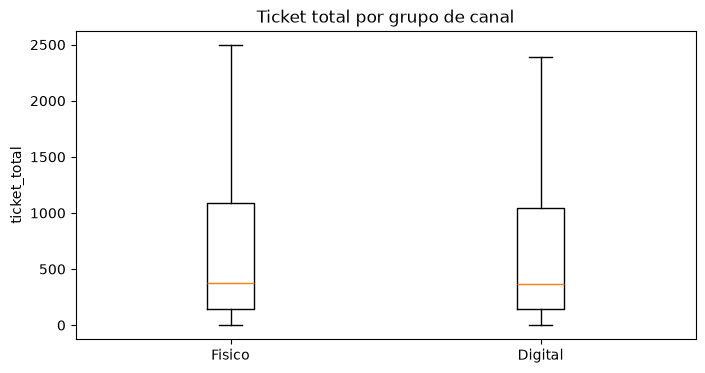

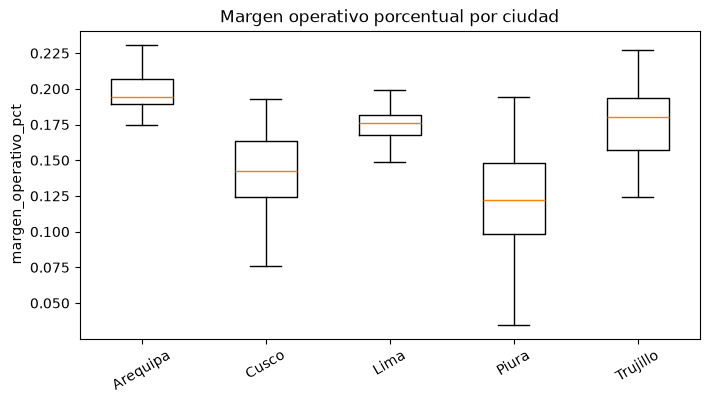

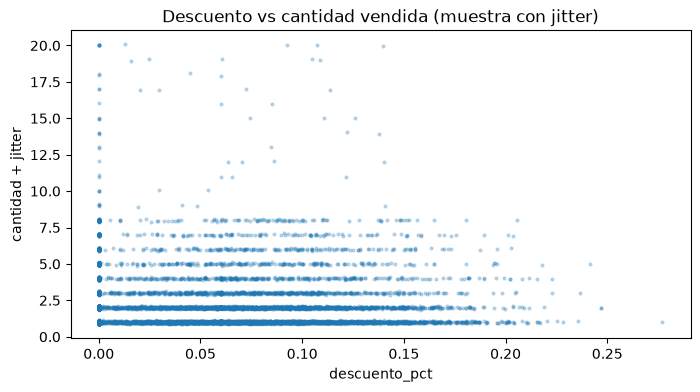

In [8]:
plt.figure(figsize=(8, 4))
plt.hist(ticket["ticket_total"], bins=60)
plt.title("Distribución de ticket_total")
plt.xlabel("ticket_total")
plt.ylabel("Frecuencia")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
datos_ticket_boxplot = [
    ticket.loc[ticket["grupo_canal"] == "Fisico", "ticket_total"].dropna(),
    ticket.loc[ticket["grupo_canal"] == "Digital", "ticket_total"].dropna(),
]
etiquetas_ticket_boxplot = ["Fisico", "Digital"]

ax.boxplot(datos_ticket_boxplot, showfliers=False)
ax.set_xticks(range(1, len(etiquetas_ticket_boxplot) + 1))
ax.set_xticklabels(etiquetas_ticket_boxplot)
ax.set_title("Ticket total por grupo de canal")
ax.set_ylabel("ticket_total")
plt.show()

ciudades_boxplot = sorted(ciudad_mes["ciudad_tienda"].dropna().unique())
datos_ciudad_boxplot = [
    ciudad_mes.loc[
        ciudad_mes["ciudad_tienda"] == ciudad,
        "margen_operativo_pct",
    ].dropna()
    for ciudad in ciudades_boxplot
]

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(datos_ciudad_boxplot, showfliers=False)
ax.set_xticks(range(1, len(ciudades_boxplot) + 1))
ax.set_xticklabels(ciudades_boxplot, rotation=30)
ax.set_title("Margen operativo porcentual por ciudad")
ax.set_ylabel("margen_operativo_pct")
plt.show()

muestra_dispersion = linea.sample(n=min(12000, len(linea)), random_state=SEED)
jitter = rng.normal(0, 0.04, size=len(muestra_dispersion))

plt.figure(figsize=(8, 4))
plt.scatter(
    muestra_dispersion["descuento_pct"],
    muestra_dispersion["cantidad"] + jitter,
    s=4,
    alpha=0.25,
)
plt.title("Descuento vs cantidad vendida (muestra con jitter)")
plt.xlabel("descuento_pct")
plt.ylabel("cantidad + jitter")
plt.show()

## 9. Funciones estadísticas auxiliares

Se definen funciones para intervalos de confianza, tamaños de efecto y formato de resultados. Las hipótesis principales se ajustan por Holm al final.

In [9]:
ALPHA = 0.05

def ic_media_t(s: pd.Series, confianza: float = 0.95) -> tuple[float, float]:
    x = pd.to_numeric(s, errors="coerce").dropna().to_numpy(dtype=float)
    n = len(x)
    media = np.mean(x)
    se = stats.sem(x)
    if n <= 1 or se == 0:
        return media, media
    return stats.t.interval(confianza, n - 1, loc=media, scale=se)

def ic_diferencia_welch(x: pd.Series, y: pd.Series, confianza: float = 0.95) -> tuple[float, float]:
    x = pd.to_numeric(x, errors="coerce").dropna().to_numpy(dtype=float)
    y = pd.to_numeric(y, errors="coerce").dropna().to_numpy(dtype=float)
    n1, n2 = len(x), len(y)
    m1, m2 = np.mean(x), np.mean(y)
    s1, s2 = np.std(x, ddof=1), np.std(y, ddof=1)
    se = math.sqrt(s1**2 / n1 + s2**2 / n2)
    df = (s1**2 / n1 + s2**2 / n2) ** 2 / ((s1**2 / n1) ** 2 / (n1 - 1) + (s2**2 / n2) ** 2 / (n2 - 1))
    return stats.t.interval(confianza, df, loc=m1 - m2, scale=se)

def hedges_g_ind(x: pd.Series, y: pd.Series) -> float:
    x = pd.to_numeric(x, errors="coerce").dropna().to_numpy(dtype=float)
    y = pd.to_numeric(y, errors="coerce").dropna().to_numpy(dtype=float)
    n1, n2 = len(x), len(y)
    s1, s2 = np.std(x, ddof=1), np.std(y, ddof=1)
    pooled = math.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
    d = (np.mean(x) - np.mean(y)) / pooled
    correction = 1 - 3 / (4 * (n1 + n2) - 9)
    return d * correction

def cramer_v(chi2: float, tabla: pd.DataFrame) -> float:
    n = tabla.to_numpy().sum()
    r, k = tabla.shape
    return math.sqrt(chi2 / (n * min(k - 1, r - 1)))

def ic_fisher_r(r: float, n: int, confianza: float = 0.95) -> tuple[float, float]:
    if abs(r) >= 1 or n <= 3:
        return r, r
    z = np.arctanh(r)
    se = 1 / math.sqrt(n - 3)
    zcrit = stats.norm.ppf(1 - (1 - confianza) / 2)
    return tuple(np.tanh([z - zcrit * se, z + zcrit * se]))

def interpretacion_decision(p_ajustado: float, efecto: float, contexto: str) -> tuple[str, str]:
    if p_ajustado < ALPHA:
        estadistica = "Se rechaza H0 con alpha=0.05 tras corrección de Holm."
    else:
        estadistica = "No se rechaza H0 con alpha=0.05 tras corrección de Holm."
    negocio = contexto
    if abs(efecto) < 0.1:
        negocio += " La magnitud del efecto es muy pequeña; se debe evitar sobredimensionar la relevancia práctica."
    return estadistica, negocio

## 10. H1 — Ticket físico frente a digital

**Pregunta:** ¿El valor promedio de los tickets difiere entre tiendas físicas y canales digitales?  
**Unidad:** ticket (`id_venta`).  
**Prueba principal:** t de Welch.  
**Efecto:** Hedges `g`.

In [10]:
h1_fisico = ticket.loc[ticket["grupo_canal"] == "Fisico", "ticket_total"]
h1_digital = ticket.loc[ticket["grupo_canal"] == "Digital", "ticket_total"]

h1_t, h1_p = stats.ttest_ind(h1_fisico, h1_digital, equal_var=False)
h1_g = hedges_g_ind(h1_fisico, h1_digital)
h1_ci = ic_diferencia_welch(h1_fisico, h1_digital)
h1_levene = stats.levene(h1_fisico, h1_digital, center="median")
h1_mwu = stats.mannwhitneyu(h1_fisico, h1_digital, alternative="two-sided")

h1_resumen = pd.DataFrame({
    "grupo": ["Fisico", "Digital"],
    "n": [len(h1_fisico), len(h1_digital)],
    "media": [h1_fisico.mean(), h1_digital.mean()],
    "mediana": [h1_fisico.median(), h1_digital.median()],
    "desviacion": [h1_fisico.std(ddof=1), h1_digital.std(ddof=1)],
    "ic95_inf": [ic_media_t(h1_fisico)[0], ic_media_t(h1_digital)[0]],
    "ic95_sup": [ic_media_t(h1_fisico)[1], ic_media_t(h1_digital)[1]],
})

display(h1_resumen)
print(f"Welch t = {h1_t:.4f}; p = {h1_p:.6f}; Hedges g = {h1_g:.4f}")
print(f"IC95 diferencia media (Fisico - Digital): [{h1_ci[0]:.4f}, {h1_ci[1]:.4f}]")
print(f"Levene/Brown-Forsythe p = {h1_levene.pvalue:.6f}")
print(f"Mann-Whitney U p (sensibilidad) = {h1_mwu.pvalue:.6f}")

,grupo,n,media,mediana,desviacion,ic95_inf,ic95_sup
0,Fisico,70781,"1,082.4517",376.4200,"2,010.2225","1,067.6421","1,097.2612"
1,Digital,29219,"1,052.2597",367.9600,"2,009.7930","1,029.2142","1,075.3051"


Welch t = 2.1603; p = 0.030757; Hedges g = 0.0150
IC95 diferencia media (Fisico - Digital): [2.7987, 57.5854]
Levene/Brown-Forsythe p = 0.052744
Mann-Whitney U p (sensibilidad) = 0.002742


## 11. H2 — Margen operativo entre ciudades

**Pregunta:** ¿Existen diferencias en el margen operativo porcentual entre ciudades físicas durante 2025-04 a 2025-12?  
**Unidad:** ciudad-mes.  
**Modelo principal:** `margen_operativo_pct ~ ciudad + mes`, con ANOVA tipo II.  
**Efecto:** eta cuadrado parcial para ciudad.

In [11]:
h2_data = (
    ciudad_mes[(ciudad_mes["periodo_mes"] >= "2025-04") & (ciudad_mes["periodo_mes"] <= "2025-12")]
    .rename(columns={"ciudad_tienda": "ciudad"})
    .copy()
)

h2_model = ols("margen_operativo_pct ~ C(ciudad) + C(periodo_mes)", data=h2_data).fit()
h2_anova = sm.stats.anova_lm(h2_model, typ=2)

h2_f = float(h2_anova.loc["C(ciudad)", "F"])
h2_p = float(h2_anova.loc["C(ciudad)", "PR(>F)"])
h2_eta = float(h2_anova.loc["C(ciudad)", "sum_sq"] / (h2_anova.loc["C(ciudad)", "sum_sq"] + h2_anova.loc["Residual", "sum_sq"]))

h2_city_summary = (
    h2_data.groupby("ciudad")["margen_operativo_pct"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)
h2_city_summary["ic95_inf"] = h2_city_summary["ciudad"].map(lambda c: ic_media_t(h2_data.loc[h2_data["ciudad"] == c, "margen_operativo_pct"])[0])
h2_city_summary["ic95_sup"] = h2_city_summary["ciudad"].map(lambda c: ic_media_t(h2_data.loc[h2_data["ciudad"] == c, "margen_operativo_pct"])[1])

display(h2_anova)
display(h2_city_summary)

print(f"F ciudad = {h2_f:.4f}; p = {h2_p:.8f}; eta parcial = {h2_eta:.4f}")

# Comparaciones post-hoc principales: Trujillo vs cada ciudad, emparejadas por mes.
wide_h2 = h2_data.pivot(index="periodo_mes", columns="ciudad", values="margen_operativo_pct")
posthoc = []
for ciudad in [c for c in wide_h2.columns if c != "Trujillo"]:
    diff = wide_h2["Trujillo"] - wide_h2[ciudad]
    t_stat, p_val = stats.ttest_rel(wide_h2["Trujillo"], wide_h2[ciudad])
    ci_diff = ic_media_t(diff)
    dz = diff.mean() / diff.std(ddof=1)
    posthoc.append({
        "comparacion": f"Trujillo - {ciudad}",
        "n_meses": diff.notna().sum(),
        "diferencia_media": diff.mean(),
        "t_pareada": t_stat,
        "p_valor": p_val,
        "efecto_dz": dz,
        "ic95_inf": ci_diff[0],
        "ic95_sup": ci_diff[1],
    })

posthoc_h2 = pd.DataFrame(posthoc)
if len(posthoc_h2):
    posthoc_h2["p_ajustado_holm"] = multipletests(posthoc_h2["p_valor"], method="holm")[1]
display(posthoc_h2)

,sum_sq,df,F,PR(>F)
C(ciudad),0.0474,4.0000,26.1480,0.0000
C(periodo_mes),0.0177,8.0000,4.8879,0.0005
Residual,0.0145,32.0000,NaN,NaN


,ciudad,count,mean,median,std,ic95_inf,ic95_sup
0,Arequipa,9,0.2021,0.1994,0.0160,0.1898,0.2144
1,Cusco,9,0.1392,0.1459,0.0446,0.1050,0.1735
2,Lima,9,0.1834,0.1791,0.0142,0.1725,0.1943
3,Piura,9,0.1208,0.1112,0.0274,0.0998,0.1419
4,Trujillo,9,0.1263,0.1379,0.0289,0.1041,0.1485


F ciudad = 26.1480; p = 0.00000000; eta parcial = 0.7657


,comparacion,n_meses,diferencia_media,t_pareada,p_valor,efecto_dz,ic95_inf,ic95_sup,p_ajustado_holm
0,Trujillo - Arequipa,9,-0.0758,-8.5435,0.0000,-2.8478,-0.0963,-0.0554,0.0001
1,Trujillo - Cusco,9,-0.0129,-1.1673,0.2767,-0.3891,-0.0385,0.0126,0.5534
2,Trujillo - Lima,9,-0.0571,-6.7399,0.0001,-2.2466,-0.0766,-0.0375,0.0004
3,Trujillo - Piura,9,0.0055,0.5547,0.5942,0.1849,-0.0174,0.0284,0.5942


## 12. H3 — Categoría principal del ticket y método de pago

**Pregunta:** ¿Existe asociación entre la categoría principal de una compra y el método de pago?  
**Unidad:** ticket.  
**Prueba principal:** chi-cuadrado de independencia.  
**Efecto:** V de Cramer.

In [12]:
tabla_h3 = pd.crosstab(ticket["categoria_ticket"], ticket["metodo_pago"])
h3_chi2, h3_p, h3_dof, h3_expected = stats.chi2_contingency(tabla_h3)
h3_v = cramer_v(h3_chi2, tabla_h3)

expected_df = pd.DataFrame(h3_expected, index=tabla_h3.index, columns=tabla_h3.columns)
condicion_esperadas = {
    "min_esperada": expected_df.min().min(),
    "pct_menor_5": (expected_df < 5).to_numpy().mean() * 100,
    "celdas_menor_1": int((expected_df < 1).to_numpy().sum()),
}

# Residuos estandarizados ajustados.
observed = tabla_h3.to_numpy(dtype=float)
expected = h3_expected
n_total = observed.sum()
row_prop = observed.sum(axis=1, keepdims=True) / n_total
col_prop = observed.sum(axis=0, keepdims=True) / n_total
residuos_ajustados = (observed - expected) / np.sqrt(expected * (1 - row_prop) * (1 - col_prop))
residuos_df = pd.DataFrame(residuos_ajustados, index=tabla_h3.index, columns=tabla_h3.columns)

top_residuos = (
    residuos_df.stack()
    .rename("residuo_ajustado")
    .reset_index()
    .rename(columns={"level_0": "categoria_ticket", "level_1": "metodo_pago"})
)
top_residuos["abs_residuo"] = top_residuos["residuo_ajustado"].abs()
top_residuos = top_residuos.sort_values("abs_residuo", ascending=False).head(10)

display(tabla_h3)
print(f"Chi2 = {h3_chi2:.4f}; gl = {h3_dof}; p = {h3_p:.6f}; V de Cramer = {h3_v:.4f}")
print(condicion_esperadas)
display(top_residuos)

metodo_pago,Billetera digital,Efectivo,Tarjeta credito,Tarjeta debito,Transferencia
categoria_ticket,,,,,
Abarrotes,3816,3983,5477,5249,695
Bebidas,2467,2781,3708,3638,481
Cuidado Personal,3113,3286,4404,4174,595
Electrohogar,4801,5363,7352,6764,942
Hogar,2957,3268,4594,4107,584
Limpieza,2274,2443,3261,3015,408


Chi2 = 30.1885; gl = 20; p = 0.066857; V de Cramer = 0.0087
{'min_esperada': np.float64(422.40705), 'pct_menor_5': np.float64(0.0), 'celdas_menor_1': 0}


,categoria_ticket,metodo_pago,residuo_ajustado,abs_residuo
22,Hogar,Tarjeta credito,2.4643,2.4643
8,Bebidas,Tarjeta debito,2.4245,2.4245
10,Cuidado Personal,Billetera digital,1.9326,1.9326
15,Electrohogar,Billetera digital,-1.8244,1.8244
5,Bebidas,Billetera digital,-1.7357,1.7357
0,Abarrotes,Billetera digital,1.6621,1.6621
12,Cuidado Personal,Tarjeta credito,-1.5430,1.5430
1,Abarrotes,Efectivo,-1.5146,1.5146
25,Limpieza,Billetera digital,1.4841,1.4841
17,Electrohogar,Tarjeta credito,1.4324,1.4324


## 13. H4 — Descuento y cantidad vendida

**Pregunta:** ¿Existe una relación monótona entre el porcentaje de descuento y la cantidad vendida por línea?  
**Unidad:** línea de venta.  
**Prueba principal:** correlación de Spearman.  
**Efecto:** `rho` de Spearman.  
**Sensibilidad:** se calcula también sin outliers de cantidad (`cantidad > 8`) y por canal.

In [13]:
h4_x = linea["descuento_pct"].astype(float)
h4_y = linea["cantidad"].astype(float)

h4_rho, h4_p = stats.spearmanr(h4_x, h4_y)
h4_ci = ic_fisher_r(h4_rho, len(linea))

linea_sin_outliers = linea[linea["cantidad"] <= 8]
h4_rho_sin, h4_p_sin = stats.spearmanr(linea_sin_outliers["descuento_pct"], linea_sin_outliers["cantidad"])

h4_por_canal = []
for canal, df_canal in linea.groupby("canal"):
    rho_c, p_c = stats.spearmanr(df_canal["descuento_pct"], df_canal["cantidad"])
    h4_por_canal.append({"canal": canal, "n": len(df_canal), "rho": rho_c, "p_valor": p_c})
h4_por_canal = pd.DataFrame(h4_por_canal)

h4_por_categoria = []
for categoria, df_cat in linea.groupby("categoria"):
    rho_cat, p_cat = stats.spearmanr(df_cat["descuento_pct"], df_cat["cantidad"])
    h4_por_categoria.append({"categoria": categoria, "n": len(df_cat), "rho": rho_cat, "p_valor": p_cat})
h4_por_categoria = pd.DataFrame(h4_por_categoria)

print(f"Spearman rho = {h4_rho:.6f}; p = {h4_p:.8f}")
print(f"IC95 aproximado de rho: [{h4_ci[0]:.6f}, {h4_ci[1]:.6f}]")
print(f"Sin outliers cantidad > 8: rho = {h4_rho_sin:.6f}; p = {h4_p_sin:.8f}")
display(h4_por_canal)
display(h4_por_categoria)

Spearman rho = 0.008656; p = 0.00001503
IC95 aproximado de rho: [0.004737, 0.012576]
Sin outliers cantidad > 8: rho = 0.009152; p = 0.00000500


,canal,n,rho,p_valor
0,App,35622,0.0126,0.0176
1,Tienda,176820,0.0075,0.0016
2,Web,37558,0.0117,0.0239


,categoria,n,rho,p_valor
0,Abarrotes,70561,0.0114,0.0024
1,Bebidas,55143,0.0052,0.2223
2,Cuidado Personal,34631,0.0221,0.0000
3,Electrohogar,29963,0.0014,0.8067
4,Hogar,24688,0.0061,0.3375
5,Limpieza,35014,0.0031,0.5644


## 14. Consolidación de pruebas de hipótesis

Se aplican valores p ajustados mediante Holm a las cuatro hipótesis principales. La interpretación combina significancia estadística, intervalo de confianza, tamaño del efecto y relevancia práctica.

In [14]:
pruebas = pd.DataFrame([
    {
        "hipotesis": "H1",
        "pregunta": "¿El ticket promedio difiere entre compras físicas y digitales?",
        "unidad_analisis": "Ticket",
        "prueba_principal": "t de Welch",
        "estadistico": h1_t,
        "p_valor": h1_p,
        "efecto_nombre": "Hedges g",
        "efecto_valor": h1_g,
        "ic95_inf": h1_ci[0],
        "ic95_sup": h1_ci[1],
        "detalle_ic": "Diferencia de medias Fisico - Digital",
    },
    {
        "hipotesis": "H2",
        "pregunta": "¿Difiere el margen operativo porcentual entre ciudades físicas durante 2025-04 a 2025-12?",
        "unidad_analisis": "Ciudad-mes",
        "prueba_principal": "Modelo lineal bloqueado + ANOVA tipo II",
        "estadistico": h2_f,
        "p_valor": h2_p,
        "efecto_nombre": "Eta cuadrado parcial",
        "efecto_valor": h2_eta,
        "ic95_inf": np.nan,
        "ic95_sup": np.nan,
        "detalle_ic": "IC por ciudad reportado en notebook",
    },
    {
        "hipotesis": "H3",
        "pregunta": "¿Existe asociación entre categoría principal del ticket y método de pago?",
        "unidad_analisis": "Ticket",
        "prueba_principal": "Chi-cuadrado de independencia",
        "estadistico": h3_chi2,
        "p_valor": h3_p,
        "efecto_nombre": "V de Cramer",
        "efecto_valor": h3_v,
        "ic95_inf": np.nan,
        "ic95_sup": np.nan,
        "detalle_ic": "No aplica directamente a chi-cuadrado global",
    },
    {
        "hipotesis": "H4",
        "pregunta": "¿Existe relación monótona entre descuento y cantidad vendida por línea?",
        "unidad_analisis": "Línea de venta",
        "prueba_principal": "Correlación de Spearman",
        "estadistico": h4_rho,
        "p_valor": h4_p,
        "efecto_nombre": "rho de Spearman",
        "efecto_valor": h4_rho,
        "ic95_inf": h4_ci[0],
        "ic95_sup": h4_ci[1],
        "detalle_ic": "IC aproximado por transformación Fisher",
    },
])

pruebas["p_valor_ajustado_holm"] = multipletests(pruebas["p_valor"], alpha=ALPHA, method="holm")[1]

interpretaciones = []
for _, row in pruebas.iterrows():
    if row["hipotesis"] == "H1":
        contexto = "El ticket físico presenta una media ligeramente mayor que el digital, pero el efecto es mínimo."
    elif row["hipotesis"] == "H2":
        contexto = "La ciudad explica diferencias relevantes de margen operativo; Trujillo muestra el deterioro esperado del escenario diagnóstico."
    elif row["hipotesis"] == "H3":
        contexto = "La asociación global entre categoría principal y método de pago no muestra evidencia suficiente ni efecto práctico relevante."
    else:
        contexto = "La relación descuento-cantidad es positiva y detectable, aunque de magnitud muy pequeña por el ruido controlado del generador."
    decision, negocio = interpretacion_decision(row["p_valor_ajustado_holm"], row["efecto_valor"], contexto)
    interpretaciones.append((decision, negocio))

pruebas["decision_estadistica"] = [x[0] for x in interpretaciones]
pruebas["interpretacion_negocio"] = [x[1] for x in interpretaciones]

display(pruebas)

,hipotesis,pregunta,unidad_analisis,prueba_principal,estadistico,p_valor,efecto_nombre,efecto_valor,ic95_inf,ic95_sup,detalle_ic,p_valor_ajustado_holm,decision_estadistica,interpretacion_negocio
0,H1,¿El ticket promedio difiere entre compras físi...,Ticket,t de Welch,2.1603,0.0308,Hedges g,0.0150,2.7987,57.5854,Diferencia de medias Fisico - Digital,0.0615,No se rechaza H0 con alpha=0.05 tras correcció...,El ticket físico presenta una media ligerament...
1,H2,¿Difiere el margen operativo porcentual entre ...,Ciudad-mes,Modelo lineal bloqueado + ANOVA tipo II,26.1480,0.0000,Eta cuadrado parcial,0.7657,NaN,NaN,IC por ciudad reportado en notebook,0.0000,Se rechaza H0 con alpha=0.05 tras corrección d...,La ciudad explica diferencias relevantes de ma...
2,H3,¿Existe asociación entre categoría principal d...,Ticket,Chi-cuadrado de independencia,30.1885,0.0669,V de Cramer,0.0087,NaN,NaN,No aplica directamente a chi-cuadrado global,0.0669,No se rechaza H0 con alpha=0.05 tras correcció...,La asociación global entre categoría principal...
3,H4,¿Existe relación monótona entre descuento y ca...,Línea de venta,Correlación de Spearman,0.0087,0.0000,rho de Spearman,0.0087,0.0047,0.0126,IC aproximado por transformación Fisher,0.0000,Se rechaza H0 con alpha=0.05 tras corrección d...,La relación descuento-cantidad es positiva y d...


## 15. Exportación de resultados

Se exportan los archivos requeridos por la tarea:

- `resultados/resumen_estadistico.csv`
- `resultados/pruebas_hipotesis.csv`

In [15]:
resumen_estadistico.to_csv(OUT_RESUMEN, index=False, encoding="utf-8")
pruebas.to_csv(OUT_PRUEBAS, index=False, encoding="utf-8")

print(f"Archivo generado: {OUT_RESUMEN.relative_to(ROOT)}")
print(f"Archivo generado: {OUT_PRUEBAS.relative_to(ROOT)}")

display(pd.read_csv(OUT_RESUMEN).head(10))
display(pd.read_csv(OUT_PRUEBAS))

Archivo generado: resultados\resumen_estadistico.csv
Archivo generado: resultados\pruebas_hipotesis.csv


,tipo,nivel,variable,descripcion,n,n_validos,n_nulos,media,mediana,moda,...,min,q1,q3,iqr,p95,max,asimetria,curtosis,conteo,porcentaje
0,numerica,linea,monto_total,Venta neta por línea,250000,250000,0,429.4519,94.0000,16.1000,...,1.8100,42.3600,263.8600,221.5000,"2,006.6065","52,471.6000",9.0800,156.0781,NaN,NaN
1,numerica,ticket,ticket_total,Total por ticket,100000,100000,0,"1,073.6299",373.8150,28.7500,...,1.9200,146.3700,"1,073.9475",927.5775,"4,527.2490","52,867.9200",5.5415,57.6591,NaN,NaN
2,numerica,linea,cantidad,Cantidad vendida por línea,250000,250000,0,2.0689,2.0000,1.0000,...,1.0000,1.0000,2.0000,1.0000,6.0000,20.0000,3.4686,20.6097,NaN,NaN
3,numerica,cliente,edad,Edad del cliente,15000,14718,282,38.3274,38.0000,18.0000,...,18.0000,30.0000,46.0000,16.0000,58.0000,80.0000,0.2243,-0.3327,NaN,NaN
4,numerica,linea,descuento_pct,Porcentaje de descuento,250000,250000,0,0.0459,0.0327,0.0000,...,0.0000,0.0000,0.0820,0.0820,0.1422,0.3161,0.8602,-0.1227,NaN,NaN
5,numerica,linea,margen_bruto_pct,Margen bruto porcentual por línea,250000,250000,0,0.2351,0.2347,0.2000,...,-0.1856,0.1786,0.3000,0.1214,0.3589,0.3982,-0.2662,-0.3893,NaN,NaN
6,numerica,ciudad_mes,margen_operativo_pct,Margen operativo porcentual ciudad-mes,180,180,0,0.1603,0.1699,0.0350,...,0.0350,0.1354,0.1905,0.0550,0.2117,0.2372,-0.6844,-0.0456,NaN,NaN
7,categorica,ticket,canal,Canal del ticket: Tienda,100000,100000,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"70,781.0000",70.7810
8,categorica,ticket,canal,Canal del ticket: Web,100000,100000,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"14,999.0000",14.9990
9,categorica,ticket,canal,Canal del ticket: App,100000,100000,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"14,220.0000",14.2200


,hipotesis,pregunta,unidad_analisis,prueba_principal,estadistico,p_valor,efecto_nombre,efecto_valor,ic95_inf,ic95_sup,detalle_ic,p_valor_ajustado_holm,decision_estadistica,interpretacion_negocio
0,H1,¿El ticket promedio difiere entre compras físi...,Ticket,t de Welch,2.1603,0.0308,Hedges g,0.0150,2.7987,57.5854,Diferencia de medias Fisico - Digital,0.0615,No se rechaza H0 con alpha=0.05 tras correcció...,El ticket físico presenta una media ligerament...
1,H2,¿Difiere el margen operativo porcentual entre ...,Ciudad-mes,Modelo lineal bloqueado + ANOVA tipo II,26.1480,0.0000,Eta cuadrado parcial,0.7657,NaN,NaN,IC por ciudad reportado en notebook,0.0000,Se rechaza H0 con alpha=0.05 tras corrección d...,La ciudad explica diferencias relevantes de ma...
2,H3,¿Existe asociación entre categoría principal d...,Ticket,Chi-cuadrado de independencia,30.1885,0.0669,V de Cramer,0.0087,NaN,NaN,No aplica directamente a chi-cuadrado global,0.0669,No se rechaza H0 con alpha=0.05 tras correcció...,La asociación global entre categoría principal...
3,H4,¿Existe relación monótona entre descuento y ca...,Línea de venta,Correlación de Spearman,0.0087,0.0000,rho de Spearman,0.0087,0.0047,0.0126,IC aproximado por transformación Fisher,0.0000,Se rechaza H0 con alpha=0.05 tras corrección d...,La relación descuento-cantidad es positiva y d...


## 16. Conclusiones de la Parte 1

1. El dataset oficial v1 permite ejecutar las pruebas estadísticas solicitadas y presenta las vistas necesarias a nivel de línea, ticket, cliente y ciudad-mes.
2. Los faltantes se encuentran en campos permitidos. Los nulos de `tiendas` corresponden a los nodos virtuales `WEB` y `APP`, por lo que son estructurales y no deben imputarse.
3. Los outliers de cantidad y tickets son coherentes con el diseño del dataset y se reportan sin eliminarse automáticamente.
4. H1 no evidencia una diferencia práctica relevante entre ticket físico y digital.
5. H2 evidencia diferencias relevantes de margen operativo entre ciudades, principalmente asociadas al escenario diagnóstico de Trujillo.
6. H3 no muestra una asociación práctica relevante entre categoría principal del ticket y método de pago.
7. H4 muestra una relación positiva entre descuento y cantidad, aunque su tamaño de efecto es pequeño.
8. Los archivos `resumen_estadistico.csv` y `pruebas_hipotesis.csv` quedan disponibles como resultados derivados para Power BI y la presentación.